In [ ]:
import scipy.io as sio
import numpy as np
import pandas as pd
import torch, os

emhmm_results_root = "../../results/251104_lextale60/emhmm"

ll = sio.loadmat(os.path.join(emhmm_results_root, "LL.mat"))
ll_array = ll['LL'].squeeze()

TrialNamesC = sio.loadmat(os.path.join(emhmm_results_root, "TrialNamesC.mat"))
TrialNamesC = TrialNamesC['TrialNamesC']
is_concrete = np.empty(TrialNamesC.shape[0], dtype=bool)

for i in range(TrialNamesC.shape[0]):
    for j in range(TrialNamesC.shape[1]):
        try:
            is_concrete[i] = "_con_" in TrialNamesC[i, j].item()[0]
        except:
            # is_concrete[i, j] = False
            print([i, j, TrialNamesC[i, j]])

[63, 4, array([], shape=(1, 0), dtype=float64)]
[69, 18, array([], shape=(1, 0), dtype=float64)]
[157, 17, array([], shape=(1, 0), dtype=float64)]


In [2]:
ll_array.shape, is_concrete.shape

((36, 160, 2), (160,))

`ll_array` = log-likelihood of each participant's similarity to Group 1 vs Group 2 for each stimulus.

Instead of summing over all stimuli, we calculate the AB scale in abstract vs concrete condition, where we sum over the corresponding trials in each condition.

Notes: Group 1 (n=27) Exploring;  Group 2 (n=9) Switching

In [3]:
LL1_con = np.nansum(ll_array[:,is_concrete,0], axis=1)
LL2_con = np.nansum(ll_array[:,is_concrete,1], axis=1)
AB_con = (LL1_con - LL2_con) / (np.abs(LL1_con) + np.abs(LL2_con))

LL1_abs = np.nansum(ll_array[:,~is_concrete,0], axis=1)
LL2_abs = np.nansum(ll_array[:,~is_concrete,1], axis=1)
AB_abs = (LL1_abs - LL2_abs) / (np.abs(LL1_abs) + np.abs(LL2_abs))

In [4]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(AB_con, AB_abs)
print(f"Paired t-test results: t-statistic = {t_stat}, p-value = {p_value}")

Paired t-test results: t-statistic = -5.475567606726508, p-value = 3.7957273163868996e-06


/tmp/ipykernel_507075/3015748606.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Condition', y='AB_scale',


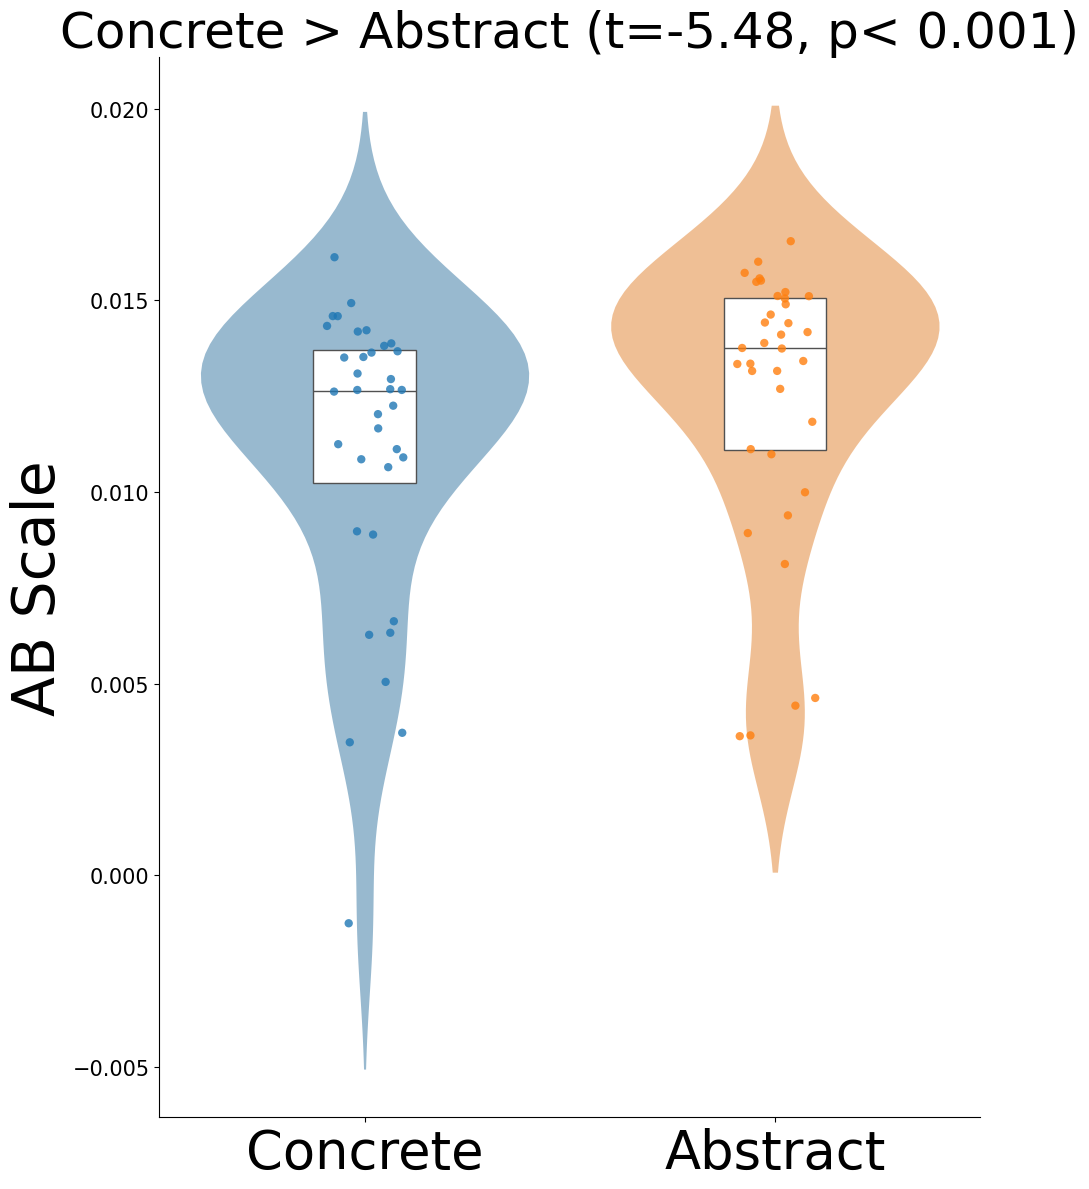

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Prepare data
df = pd.DataFrame({
    'Participant': range(len(AB_con)),
    'Concrete': AB_con,
    'Abstract': AB_abs
}).melt(id_vars='Participant', var_name='Condition', value_name='AB_scale')

# Choose colors (you can tweak these)
palette = {"Abstract": "tab:orange", "Concrete": "tab:blue"}  # blue vs orange

plt.figure(figsize=(10, 12))

# Violin plot (distribution)
sns.violinplot(data=df, x='Condition', y='AB_scale',
               inner=None, linewidth=0, palette=palette, alpha=0.5)

# Boxplot overlay (median + IQR)
sns.boxplot(data=df, x='Condition', y='AB_scale', width=0.25,
            showcaps=False, boxprops={'facecolor':'white', 'zorder':3},
            showfliers=False, whiskerprops={'linewidth':0}, zorder=3)

# Jittered individual points
sns.stripplot(data=df, x='Condition', y='AB_scale', hue='Condition',
              palette=palette, dodge=False, alpha=0.8, size=6, jitter=0.1, zorder=4)

# Clean up legend (duplicate hue)
plt.legend([],[], frameon=False)

# Significance annotation
y_max = df['AB_scale'].max()
y_sig = y_max + 0.05 * (df['AB_scale'].max() - df['AB_scale'].min())

# Labels & title
plt.title(f"Concrete > Abstract (t={t_stat:.2f}, p< 0.001)", fontsize=36)
plt.xticks(fontsize=38)  # Adjust the font size as needed
plt.yticks(fontsize=15)  # Adjust the font size as needed
plt.xlabel('')
plt.ylabel("AB Scale", fontsize=42)
sns.despine()
plt.tight_layout()
plt.show()

Interpretation: Participants adopting a more exploring pattern (i.e. more similar to Group 1) when viewing abstract pairs.